ML: Problem 1: Classification Task 

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn import metrics

a.) Data Preprocessing

In [71]:
# Load the dataset and convert to DataFrame
df= pd.read_csv('ML_Task1_Customer_Health_Profile.csv')
df.head(10)

,Age,BMI,Smoking_Habit,Exercise_Frequency,Blood_Pressure,Health_Risk
0,20,30.33,No,Moderate,157,Low
1,23,30.30,No,Low,117,Low
2,23,31.55,Yes,High,162,High
3,59,19.94,Yes,High,168,High
4,29,34.41,No,High,145,Medium
5,39,32.79,Yes,High,154,Low
6,41,NaN,Yes,Low,163,High
7,56,29.07,No,High,170,Medium
8,43,22.92,Yes,High,159,Low
9,26,29.97,No,Moderate,106,Medium


Data Exploration

In [72]:
# Basic data exploration
print(f"We are working with the dataset of {df.shape}\n")

# Check for basic stats
print(f"Basic states \n{df.describe()}\n")

# Check for missing values
print(f"Missing values \n{df.isnull().sum()}\n")

# Check for value count on 2 items
print(df['Exercise_Frequency'].value_counts())
print(df['Smoking_Habit'].value_counts())

# Check for duplicates
print(f"Duplicate records: {df.duplicated().sum()}\n")

We are working with the dataset of (3500, 6)

Basic states 
               Age          BMI  Blood_Pressure
count  3500.000000  3150.000000     3500.000000
mean     39.400000    26.690314      140.128571
std      11.696481     4.944937       23.045069
min      20.000000    18.010000      100.000000
25%      29.000000    22.410000      120.000000
50%      39.000000    26.815000      141.000000
75%      49.000000    31.110000      160.000000
max      59.000000    35.000000      179.000000

Missing values 
Age                     0
BMI                   350
Smoking_Habit           0
Exercise_Frequency      0
Blood_Pressure          0
Health_Risk             0
dtype: int64

Exercise_Frequency
High        1194
Low         1193
Moderate    1113
Name: count, dtype: int64
Smoking_Habit
No     1751
Yes    1749
Name: count, dtype: int64
Duplicate records: 1


Handle Duplicate value

In [73]:
#1. Drop the duplicates
df= df.drop_duplicates()
# Recheck the dataset
print(f"We are working with the updated dataset of {df.shape}\n")

We are working with the updated dataset of (3499, 6)


 Handle missing values

In [74]:
#2. Handle missing values
# Calculate the mean of the BMI column, ignoring NaN values
mean_bmi = df['BMI'].mean()
# Fill the missing values in the BMI column with the mean value
df['BMI'] = df['BMI'].fillna(mean_bmi)
# Check for basic stats
print(f"Basic states \n{df.describe()}\n")

Basic states 
               Age          BMI  Blood_Pressure
count  3499.000000  3499.000000     3499.000000
mean     39.402686    26.690314      140.130609
std      11.697072     4.691775       23.048048
min      20.000000    18.010000      100.000000
25%      29.000000    22.895000      120.000000
50%      39.000000    26.690314      141.000000
75%      49.000000    30.655000      160.000000
max      59.000000    35.000000      179.000000


In [75]:
# Check for missing values
print(f"Missing values \n{df.isnull().sum()}\n")

Missing values 
Age                   0
BMI                   0
Smoking_Habit         0
Exercise_Frequency    0
Blood_Pressure        0
Health_Risk           0
dtype: int64


Encoding for Categorical features

In [76]:
# Label encode Smoking_Habit
label_encoder = LabelEncoder()
df['Smoking_Habit'] = label_encoder.fit_transform(df['Smoking_Habit'])
# "No" becomes 0, "Yes" becomes 1

# Custom mapping for ordinal encoding
exercise_mapping = {'Low': 0, 'Moderate': 1, 'High': 2}
df['Exercise_Frequency'] = df['Exercise_Frequency'].map(exercise_mapping)

# Label and encode BMI to an interpretable meaning.
def categorize_bmi(bmi):
    if bmi < 18.5:
        return 'Underweight'
    elif 18.5 <= bmi < 25:
        return 'Healthy weight'
    elif 25 <= bmi < 30:
        return 'Overweight'
    else:
        return 'Obese'

df['BMI_Category'] = df['BMI'].apply(categorize_bmi)

BMI_Category_mapping = {'Underweight': 0, 'Healthy weight': 1, 'Overweight': 2, 'Obese':3}
df['BMI_Category_lable'] = df['BMI_Category'].map(BMI_Category_mapping)


Check and visual each feature's distributions

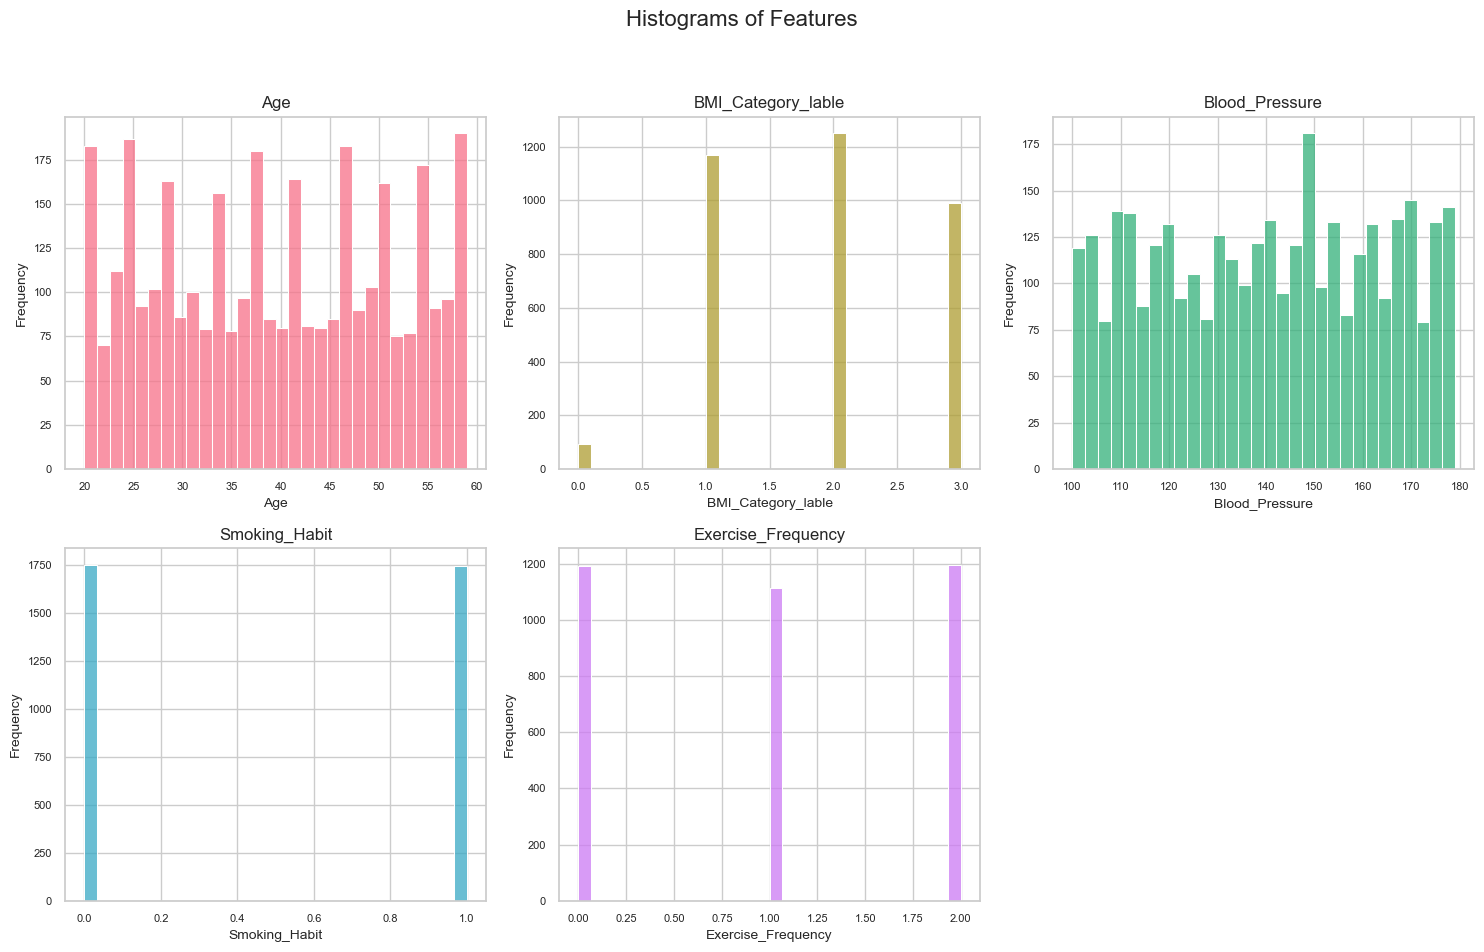

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style and color palette
sns.set(style="whitegrid")
colors = sns.color_palette("husl", 5)  # Use a colorful palette

# Create histograms with smaller font size
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Histograms of Features', fontsize=16)

# Plot each histogram
columns = ['Age', 'BMI_Category_lable', 'Blood_Pressure', 'Smoking_Habit', 'Exercise_Frequency']
for i, column in enumerate(columns):
    sns.histplot(df[column], bins=30, color=colors[i], ax=axes[i//3, i%3], kde=False)
    axes[i//3, i%3].set_title(column, fontsize=12)
    axes[i//3, i%3].set_xlabel(column, fontsize=10)
    axes[i//3, i%3].set_ylabel('Frequency', fontsize=10)
    axes[i//3, i%3].tick_params(axis='both', which='major', labelsize=8)

# Remove the empty subplot
fig.delaxes(axes[1, 2])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Normalize the features of the dataset

In [78]:
# Initialize MinMaxScaler
scaler = MinMaxScaler()

# Apply MinMaxScaler to numerical features
df[['BMI_Category_lable', 'Blood_Pressure','Exercise_Frequency','Smoking_Habit']] = scaler.fit_transform(df[['BMI_Category_lable', 'Blood_Pressure','Exercise_Frequency','Smoking_Habit']])

# Check scaled values
print('Result of the MinMaxScalr \n',df[['BMI_Category_lable', 'Blood_Pressure','Exercise_Frequency','Smoking_Habit']].head())

Result of the MinMaxScalr 
    BMI_Category_lable  Blood_Pressure  Exercise_Frequency  Smoking_Habit
0            1.000000        0.721519                 0.5            0.0
1            1.000000        0.215190                 0.0            0.0
2            1.000000        0.784810                 1.0            1.0
3            0.333333        0.860759                 1.0            1.0
4            1.000000        0.569620                 1.0            0.0


Perform the correlation Matrix

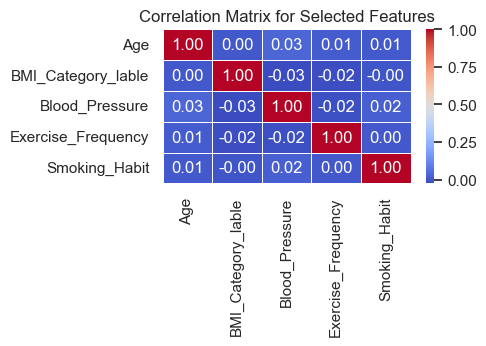

In [79]:
selected_features = ['Age', 'BMI_Category_lable', 'Blood_Pressure', 'Exercise_Frequency', 'Smoking_Habit']
df_selected = df[selected_features]
corr_matrix = df_selected.corr()

plt.figure(figsize=(4, 2))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix for Selected Features')
plt.show()

Split the train and testing set

In [80]:
Column_to_drop = ['BMI','BMI_Category','Health_Risk']

X = df.drop(columns= Column_to_drop)
y = df['Health_Risk']

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.3, random_state= 42)

In [81]:
#Check shape of the training and testing set
print('Shape of X training set {}'.format(X_train.shape),'&',' Size of Y training set {}'.format(y_train.shape))
print('Shape of X test set {}'.format(X_test.shape),'&',' Size of Y test set {}'.format(y_test.shape))

Shape of X training set (2449, 5) &  Size of Y training set (2449,)
Shape of X test set (1050, 5) &  Size of Y test set (1050,)


b.) Model Building

Train the model using the training set

In [82]:
# Initialize the Decision Tree model
dt = DecisionTreeClassifier(random_state=42)

# Train the model
dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

Evaluate the model's performance on the test set and report the accuracy

In [83]:
# Make predictions on Training and Test 
y_pred_train_dt = dt.predict(X_train)
y_pred_dt = dt.predict(X_test)

# Evaluate the model
print('Predictions Accuracy: \n')
accuracy_train_dt =accuracy_score(y_train,y_pred_train_dt)
print(f'Decision Tree training Accuracy: {accuracy_train_dt:.4f}')
accuracy_dt = accuracy_score(y_test, y_pred_dt)
print(f'Decision Tree testing Accuracy: {accuracy_dt:.4f}')

Predictions Accuracy: 

Decision Tree training Accuracy: 0.9857
Decision Tree testing Accuracy: 0.3352


c.) Analysis

Visualize the distribution of the Health_Risk categories

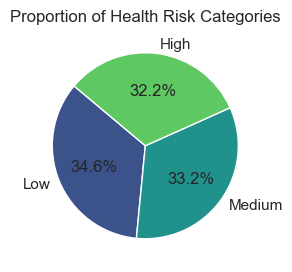

In [84]:
# Calculate the percentage distribution
health_risk_counts = df['Health_Risk'].value_counts()
health_risk_labels = health_risk_counts.index

# Create the pie chart
plt.figure(figsize=(3, 8))
plt.pie(health_risk_counts, labels=health_risk_labels, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('viridis', len(health_risk_labels)))
plt.title('Proportion of Health Risk Categories', fontsize=12)
plt.show()

Insights

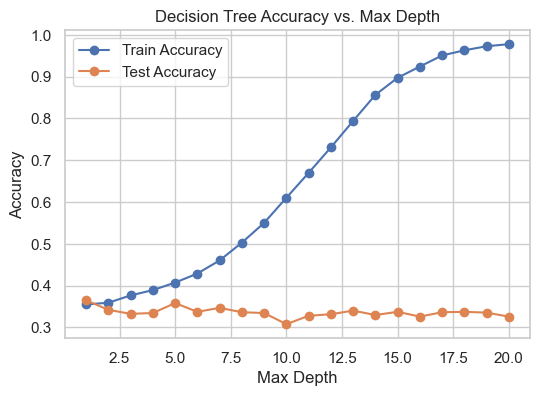

In [85]:
import matplotlib.pyplot as plt


# List to store accuracies for different max_depth values
train_accuracies = []
test_accuracies = []

# Testing max_depth from 1 to 20
max_depth_values = range(1, 21)  

for max_depth in max_depth_values:
    # Initialize the Decision Tree model with the current max_depth
    dt = DecisionTreeClassifier(max_depth=max_depth, random_state=42)
    
    # Train the model
    dt.fit(X_train, y_train)
    
    # Calculate accuracy on the training set
    y_train_pred = dt.predict(X_train)
    train_accuracy = accuracy_score(y_train, y_train_pred)
    train_accuracies.append(train_accuracy)
    
    # Calculate accuracy on the test set
    y_test_pred = dt.predict(X_test)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    test_accuracies.append(test_accuracy)

# Plotting the accuracies
plt.figure(figsize=(6, 4))
plt.plot(max_depth_values, train_accuracies, label='Train Accuracy', marker='o')
plt.plot(max_depth_values, test_accuracies, label='Test Accuracy', marker='o')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.title('Decision Tree Accuracy vs. Max Depth')
plt.legend()
plt.grid(True)
plt.show()

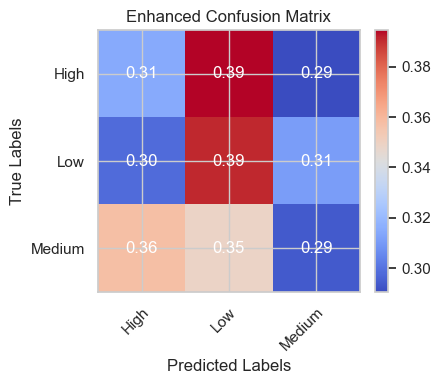

In [86]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

# Generate the confusion matrix and get class lables
cm = confusion_matrix(y_test, y_pred_dt, normalize='true')
classes = np.unique(y_test)

# Plot the confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, interpolation='nearest', cmap='coolwarm')  
ax.figure.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# Add titles and labels
ax.set(
    xticks=np.arange(cm.shape[1]),
    yticks=np.arange(cm.shape[0]),
    xticklabels=classes,
    yticklabels=classes,
    title="Enhanced Confusion Matrix",
    ylabel="True Labels",
    xlabel="Predicted Labels"
)

# Rotate the x-axis labels
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

# Add values to each cell and make sure the colors are visible
thresh = cm.max() / 2.  
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j, i, f"{cm[i, j]:.2f}",
            ha="center", va="center",
            color="white" if cm[i, j] > thresh else "black"
        )

# Improve layout and show the plot
plt.tight_layout()
plt.show()